# Simulation Based Inference to Remove Sampling Bias - inference for both variants independently

Model  with parameters `beta`, `delta`, `mu_inf_SC`, `mu_inf_SI`, `mu_inf_AI`, `mu_inf_AC`, `mu_inf_AA`, `mu_susc_C`, `mu_susc_I`, `mu_low_conf`, `mu_high_conf`.

In [1]:
import os
import pickle
from itertools import product
from time import perf_counter

import bayesflow as bf
import numpy as np
import pandas as pd
import tensorflow as tf
from bayesflow.simulation import GenerativeModel, Prior, Simulator, ContextGenerator
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from tarp import get_tarp_coverage
from tqdm import tqdm

from helper_functions import normalize_household_data, percentage_infection_age
from network_config import load_model
from plotting_functions import sampling_parameter_cis

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
job_array_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0))
batch_size = 128

train_network = False
presimulate = False

## Define model and prior

In [3]:
param_names = ['beta', 'delta',
               'mu_inf_SC', 'mu_inf_SI', 'mu_inf_AI', 'mu_inf_AC', 'mu_inf_AA',
               'mu_susc_C', 'mu_susc_I',
               'mu_low_conf', 'mu_high_conf']
n_params = len(param_names)

In [4]:
# define the prior    
def prior(batch_size: int) -> np.ndarray:
    # log(beta), delta, log(mu_...)
    param_batch = np.random.normal(0, 1, (batch_size, n_params))
    return param_batch

# for normalization of the parameters
prior_mean = np.zeros(n_params)
prior_std = np.ones(n_params)

assert prior_mean.size == prior_std.size, 'Number of parameters do not match'
assert prior_mean.size == prior(1).shape[1], \
    'Number of parameters do not match in prior'

In [5]:
# check if GPU is available
n_gpus = len(tf.config.experimental.list_physical_devices('GPU'))
print("Num GPUs Available: ", n_gpus)

if n_gpus > 0:
    def simulator(log_params: np.ndarray,
                  batchable_context: [str, float],
                  non_batchable_context: str,
                  minimal_length: int = 9)  -> np.ndarray:
        # gpu cannot handle R modules for some reason
        raise NotImplementedError('simulator function not implemented')
else:
    from Simulator.simulator import simulator

# if name starts with mu, create log name
log_param_names = []
for p_name in param_names:
    if p_name == 'delta':
        log_param_names.append(p_name)
    else:
        log_param_names.append(f'log({p_name})')
    
assert n_params == prior_mean.size, 'Number of parameters in normalization do not match names'
print(f"Number of parameters: {n_params}")

Num GPUs Available:  0


Attaching package: ‘dplyr’



    filter, lag



    intersect, setdiff, setequal, union


Attaching package: ‘actuar’



    sd, var



    cm




Number of parameters: 11


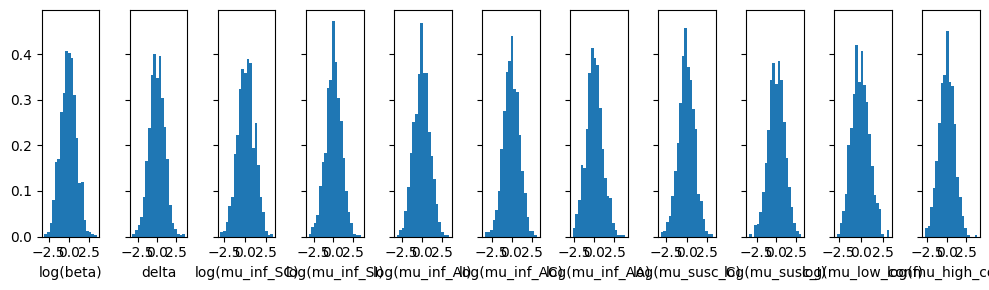

In [6]:
# plot prior
fix, ax = plt.subplots(1, len(log_param_names), figsize=(10, 3), sharey=True, tight_layout=True)
n_samples = 1000
prior_samples = prior(n_samples)
for i in range(len(log_param_names)):
    ax[i].hist(prior_samples[:, i], bins=20, density=True)
    ax[i].set_xlabel(log_param_names[i])
plt.show()

## Define the generative model for BayesFlow

In [7]:
bayesflow_prior = Prior(
    batch_prior_fun=prior,
    param_names=log_param_names
)

alpha_community_infection = np.array([0.0005, 0.002, 0.003])
omicron_community_infection = alpha_community_infection * 10
def batchable_context(var):
    sel = np.random.choice(['pedcov', 'random'])
    if var == 'alpha':
        a = np.random.choice(alpha_community_infection)
    elif var == 'omicron':
        a = np.random.choice(omicron_community_infection)
    else:
        raise ValueError('Invalid variant')
    return np.array([sel, a])

context_gen = ContextGenerator(
    batchable_context_fun=batchable_context,
    non_batchable_context_fun=lambda : np.random.choice(['alpha', 'omicron']),
    use_non_batchable_for_batchable=True
)
bayes_simulator = Simulator(
    simulator_fun=simulator,
    context_generator=context_gen
)
generative_model = GenerativeModel(
    prior=bayesflow_prior, 
    simulator=bayes_simulator,
    skip_test=True
)

## Generate training data

In [8]:
presim_folder = 'presimulations'

if presimulate:    
    os.makedirs(presim_folder+'/files', exist_ok=True)
    np.random.seed(42)
    print('presimulating')
    start_time = perf_counter()
    n_rounds = 20
    for job_1000 in range(n_rounds):
        add_to_id = job_1000 * 1000
        # we create on batch per job and save it in a folder
        print(f'presimulating job {job_array_id+add_to_id}')
        
        generative_model.presimulate_and_save(batch_size=batch_size, 
                                              folder_path=f'{presim_folder}/files',
                                              iterations_per_epoch=1,
                                              epochs=1,
                                              extend_from=job_array_id+add_to_id,
                                              disable_user_input=True)
    end_time = perf_counter()
    print(f'simulation time: {(end_time-start_time)/60} minutes')
    print(f'simulation time per sample: {(end_time-start_time)/60/batch_size/n_rounds} minutes')
    #exit()

In [9]:
# generate validation data
sim_folder = 'sim_data'
valid_file_name = "valid_data"

np.random.seed(42)
n_valid = 256
valid_data_dict = {}
for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):
    valid_file_name_vs = f"{valid_file_name}_{variant}_{selection}"
    if os.path.exists(f'{sim_folder}/{valid_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'rb') as f:
            valid_data_dict[f'{variant}_{selection}'] = pickle.load(f)
    else:
        print(f"Simulating validation data for {variant} with {selection}")
        os.makedirs(sim_folder, exist_ok=True)
        if variant == 'alpha':
            community_infection = alpha_community_infection
        else:
            community_infection = omicron_community_infection

        new_valid_data = {
            'prior_draws': bayesflow_prior(n_valid // 2)['prior_draws'],
            'sim_batchable_context': np.array([[selection, np.random.choice(community_infection)] for _ in range(n_valid // 2)]),
            'sim_non_batchable_context': variant,
        }
        new_valid_data['sim_data'] = np.array([
            simulator(log_params=params,
                      batchable_context=context,
                      non_batchable_context=variant)
            for params, context in zip(new_valid_data['prior_draws'], new_valid_data['sim_batchable_context'])
        ])
        # save the data
        with open(f'{sim_folder}/{valid_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_valid_data, f)
        valid_data_dict[f'{variant}_{selection}'] = new_valid_data

# we cannot use both variants at the same time for validation since variant is not batchable
valid_data_alpha = {key: np.concatenate((valid_data_dict['alpha_pedcov'][key],
                                   valid_data_dict['alpha_random'][key])
                                  ) for key in valid_data_dict['alpha_pedcov'].keys() if key != 'sim_non_batchable_context'}
valid_data_alpha['sim_non_batchable_context'] = 'alpha'
valid_data_omicron = {key: np.concatenate((valid_data_dict['omicron_pedcov'][key],
                                   valid_data_dict['omicron_random'][key])
                                  ) for key in valid_data_dict['omicron_pedcov'].keys() if key != 'sim_non_batchable_context'}
valid_data_omicron['sim_non_batchable_context'] = 'omicron'

In [10]:
def renormalize_params(params: np.ndarray, keep_log_transform: bool = False) -> np.ndarray:
    un_scaled_params = params.copy()
    un_scaled_params = un_scaled_params * prior_std + prior_mean
    
    if not keep_log_transform:
        for p_i in range(n_params):
            if log_param_names[p_i][:3] != 'log':
                continue
                
            if un_scaled_params.ndim == 2:
                un_scaled_params[:, p_i] = np.exp(un_scaled_params[:, p_i])
            elif un_scaled_params.ndim == 3:
                 un_scaled_params[:, :, p_i] = np.exp(un_scaled_params[:, :, p_i])
            else:
                raise ValueError('Invalid number of dimensions')
    return un_scaled_params

## Load neural network architectures

In [85]:
# settings
network_id = 7
amortizer_folder = 'amortizer'
results_folder = 'results_both_variants'
os.makedirs(results_folder, exist_ok=True)

trainer, amortizer_name = load_model(
    model_id=network_id,
    n_params=n_params,
    generative_model=generative_model,
    prior_mean=prior_mean,
    prior_std=prior_std,
    train_network=train_network,
    valid_data=valid_data_alpha,
    presim_folder=presim_folder + '/files',
    amortizer_folder=amortizer_folder,
    amortizer_return_attention_weights=False,  # only needed for diagnostics of attention
    #keep_selection_inference='pedcov'  # needed to validate models trained only on one selection procedure
)

INFO:network_config: Model Configuration: amortizer_7_group_attention-9_layers
INFO:network_config:Checkpoint path: amortizer/amortizer_7_group_attention-9_layers 
INFO:root:Loaded loss history from amortizer/amortizer_7_group_attention-9_layers/history_164.pkl.
INFO:root:Networks loaded from amortizer/amortizer_7_group_attention-9_layers/ckpt-164
INFO:network_config:Networks loaded from amortizer/amortizer_7_group_attention-9_layers/ckpt-160
INFO:network_config:Best validation loss at epoch 160 with 5.734974384307861


## Check the training convergence

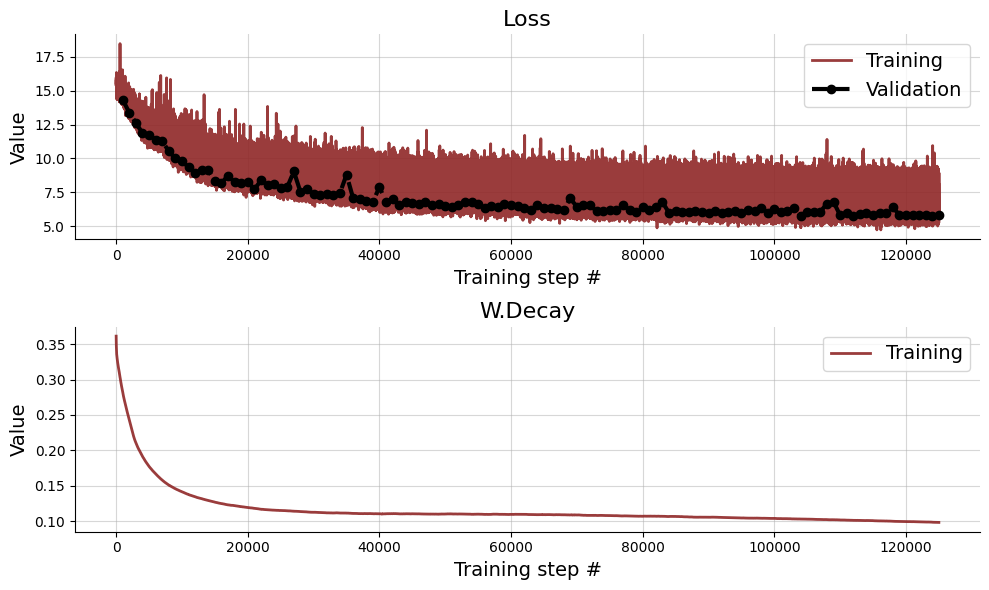

In [12]:
history = trainer.loss_history.get_plottable()
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [13]:
test_sims_alpha = trainer.configurator(valid_data_alpha)
test_sims_omicron = trainer.configurator(valid_data_omicron)

In [38]:
# we need to join samples from both variants to check SBC and other diagnostics
posterior_samples_alpha = trainer.amortizer.sample(test_sims_alpha, n_samples=500)
posterior_samples_omicron = trainer.amortizer.sample(test_sims_omicron, n_samples=500)
posterior_samples = np.concatenate((posterior_samples_alpha, posterior_samples_omicron), axis=0)
posterior_samples = renormalize_params(posterior_samples, keep_log_transform=True)

if isinstance(test_sims_alpha, list):  # for ensemble
    prior_draws_alpha = renormalize_params(test_sims_alpha[0]["parameters"], keep_log_transform=True)
    prior_draws_omicron = renormalize_params(test_sims_omicron[0]["parameters"], keep_log_transform=True)
else:
    prior_draws_alpha = renormalize_params(test_sims_alpha["parameters"], keep_log_transform=True)
    prior_draws_omicron = renormalize_params(test_sims_omicron["parameters"], keep_log_transform=True)
prior_draws = np.concatenate((prior_draws_alpha, prior_draws_omicron), axis=0)

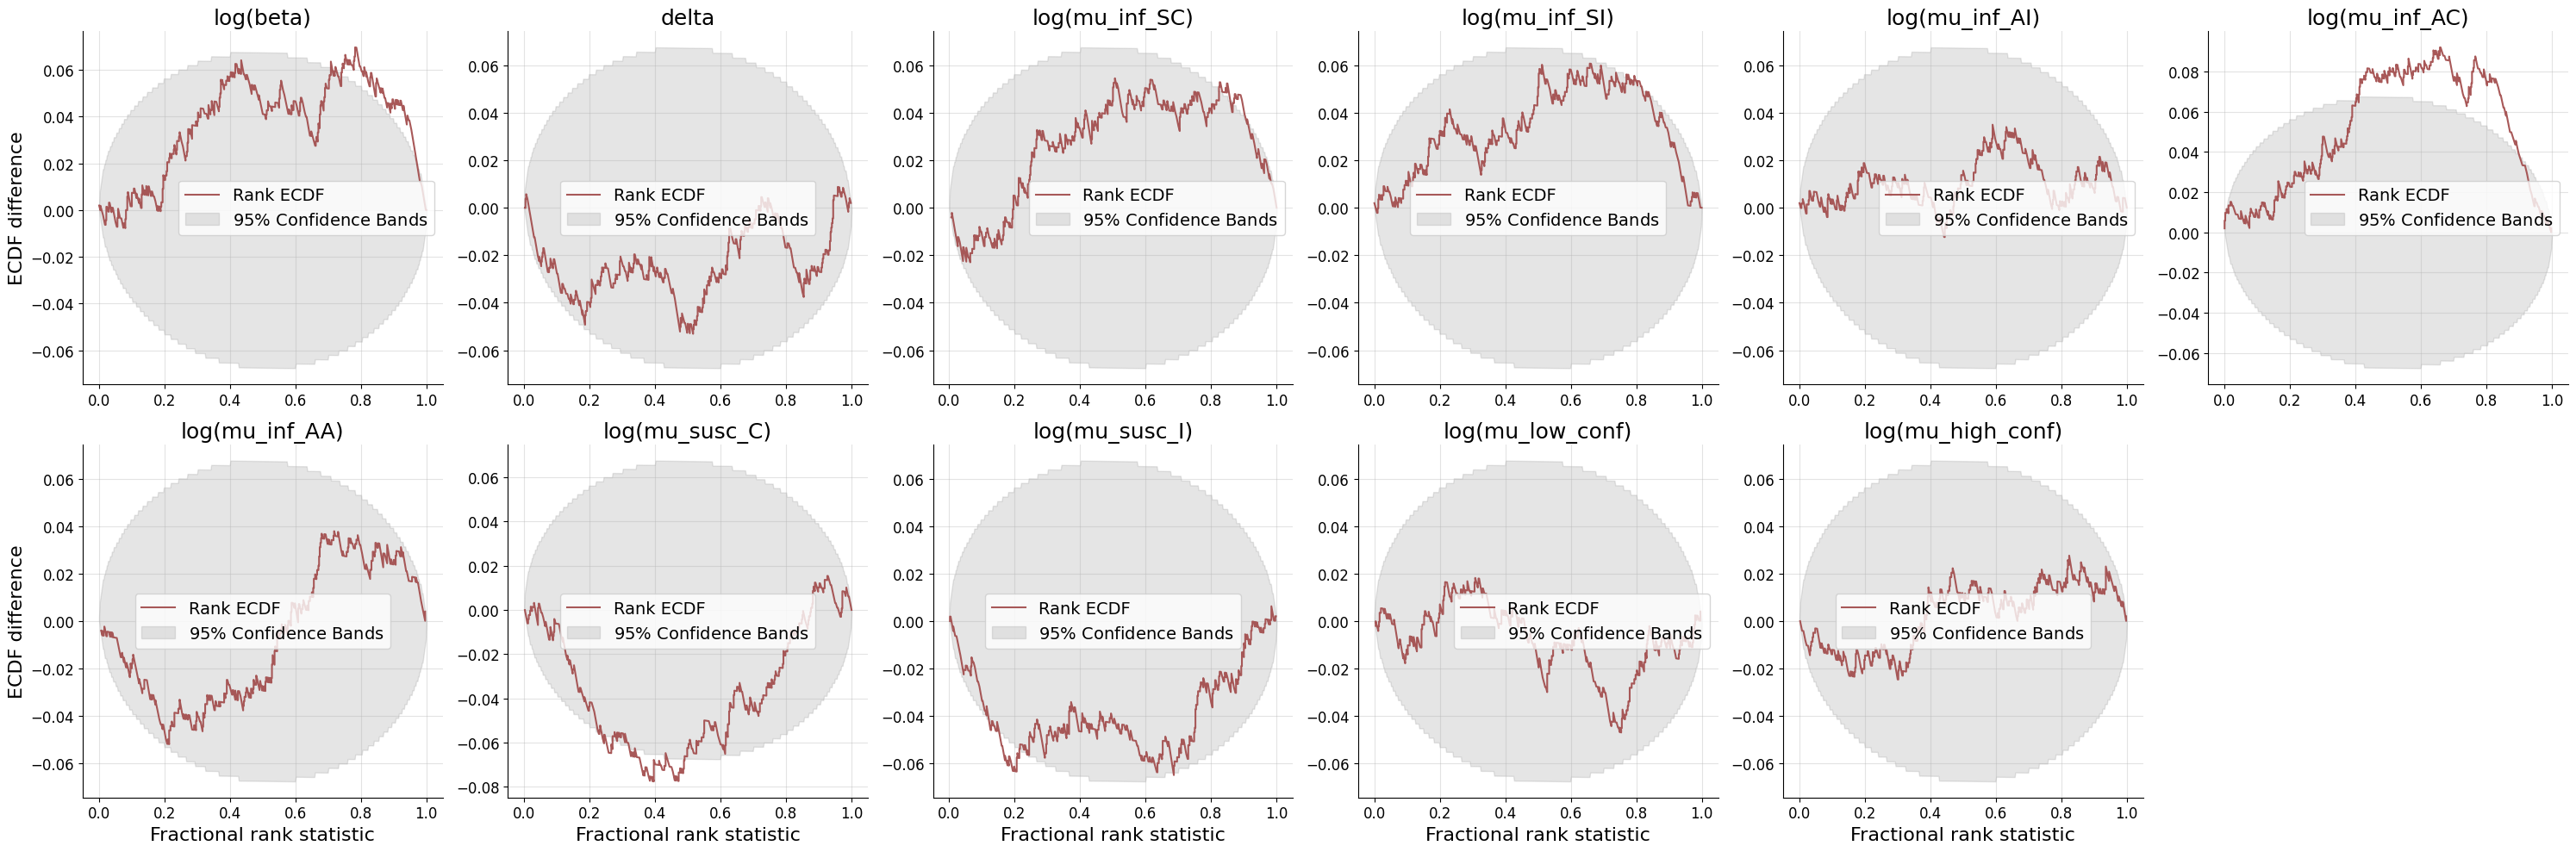

In [30]:
fig = bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, 
                                   difference=True, param_names=log_param_names)
fig.savefig(f'{results_folder}/{amortizer_name}_sbc.png')

In [31]:
# remove nan
remove = np.any(np.isnan(posterior_samples), axis=(1, 2))
if np.any(remove):
    print(f"Removing {np.sum(remove)} entries with nan")

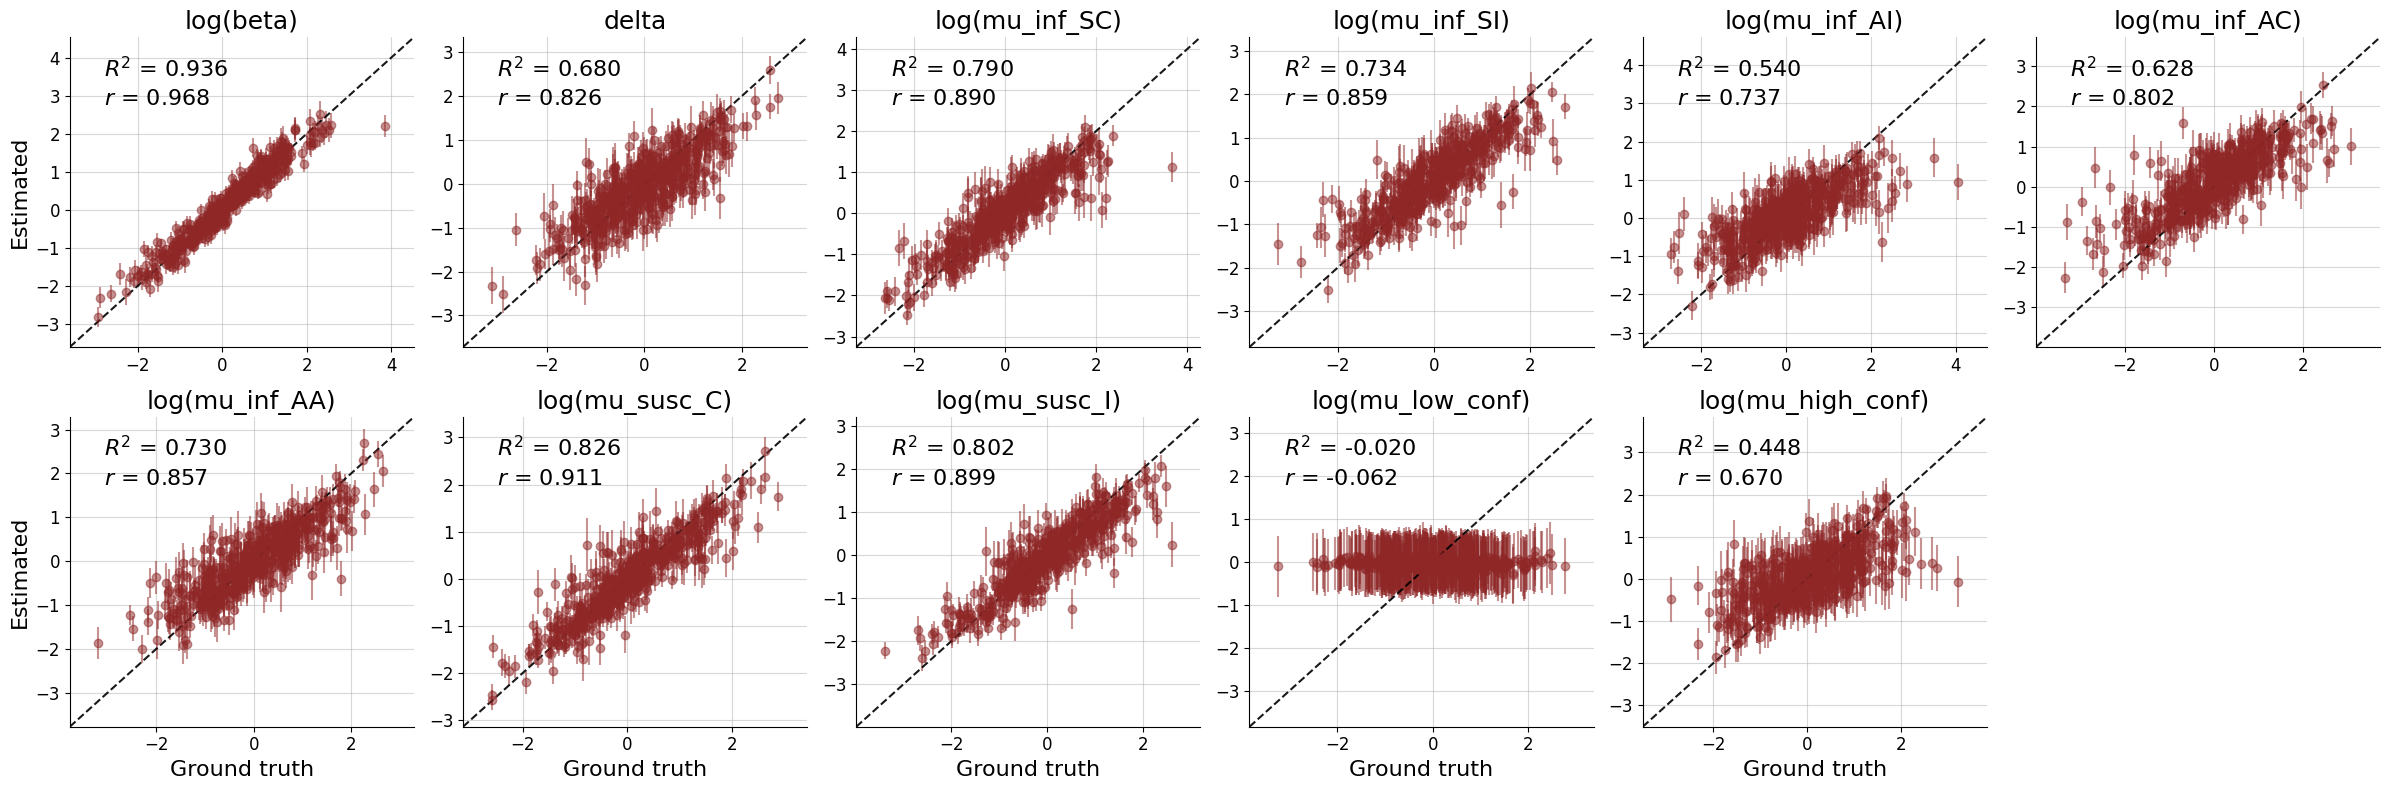

In [32]:
bf.diagnostics.plot_recovery(posterior_samples[~remove], prior_draws[~remove], param_names=log_param_names);

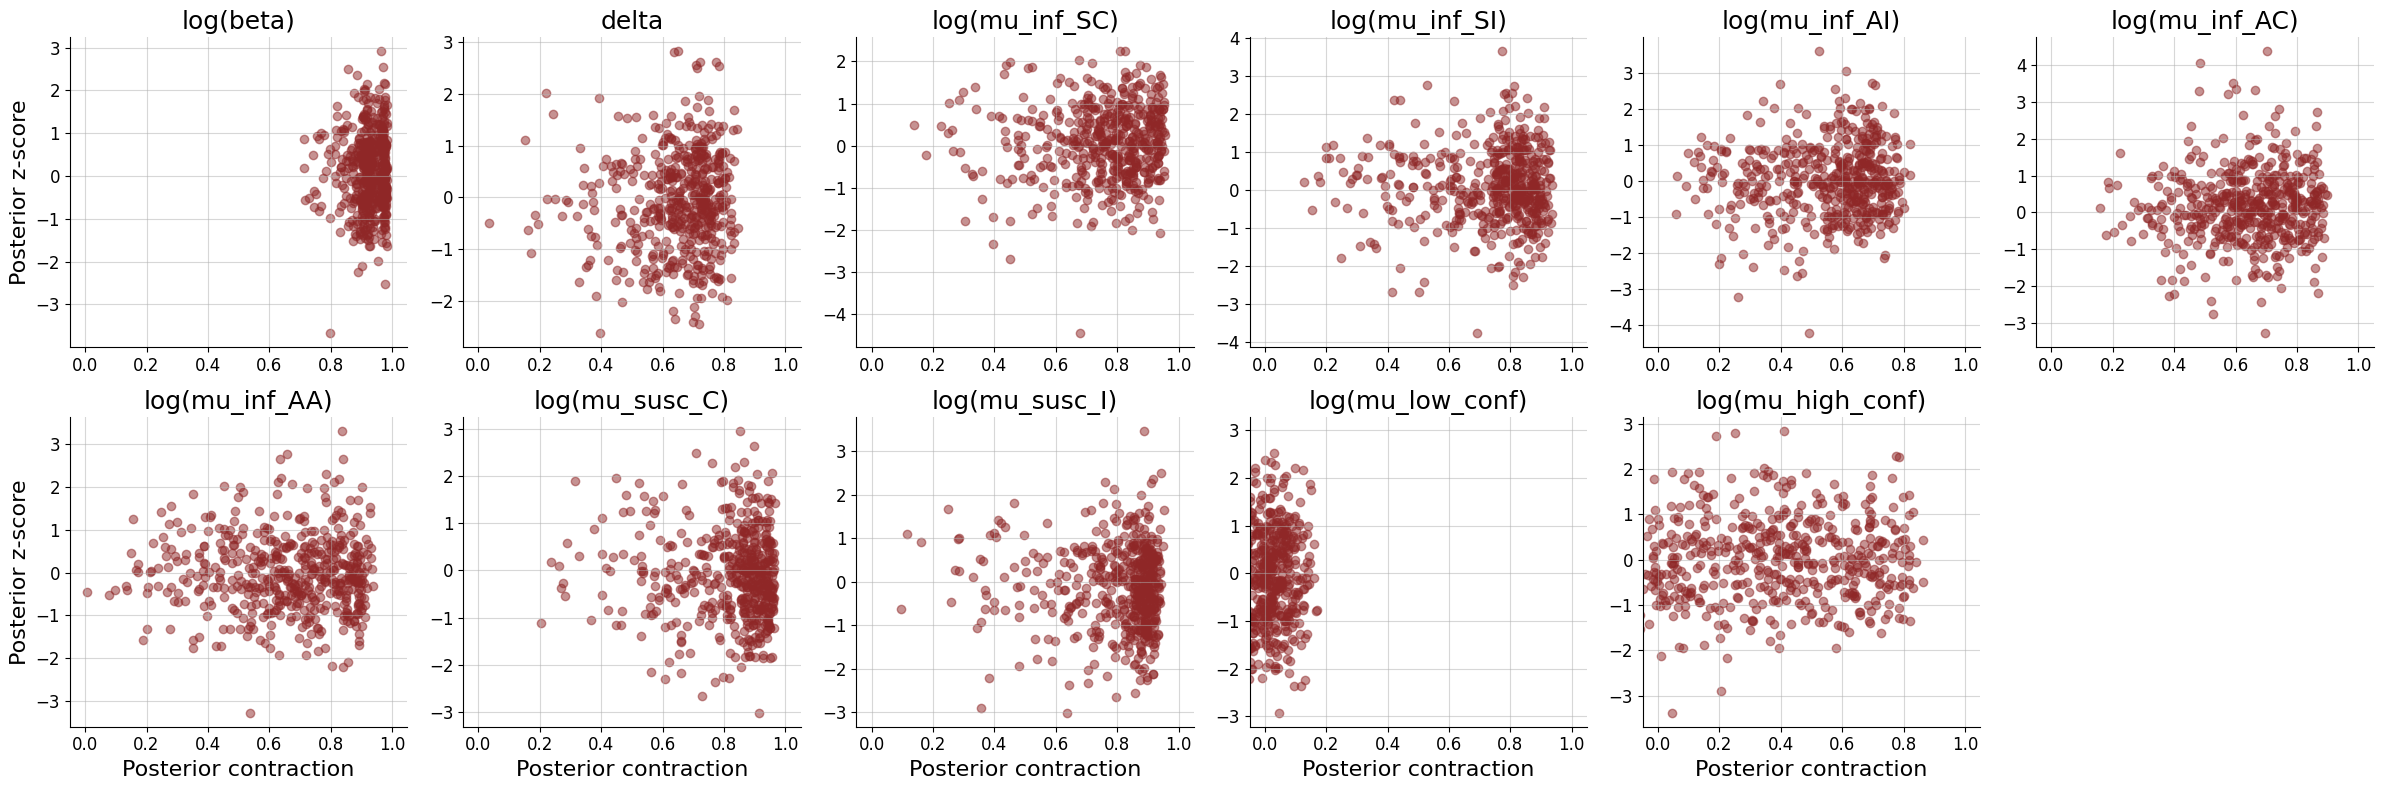

In [33]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=log_param_names);

In [75]:
posterior_samples_reshaped = posterior_samples.reshape(posterior_samples.shape[1], 
                                                       posterior_samples.shape[0], 
                                                       posterior_samples.shape[2])

# random sample with dependence on data
references_1 = np.mean(test_sims_alpha['summary_conditions'], axis=(1,2,3))
references_2 = np.mean(test_sims_omicron['summary_conditions'], axis=(1,2,3))
references = np.concatenate((references_1, references_2), axis=0)
references = references + np.random.uniform(-references.std(), references.std(), references.shape)
references = np.array([references.T] * n_params).T

ecp_bootstrap, alpha = get_tarp_coverage(posterior_samples_reshaped, prior_draws,
                                         references=references, bootstrap=True)

100%|██████████| 100/100 [00:00<00:00, 136.04it/s]


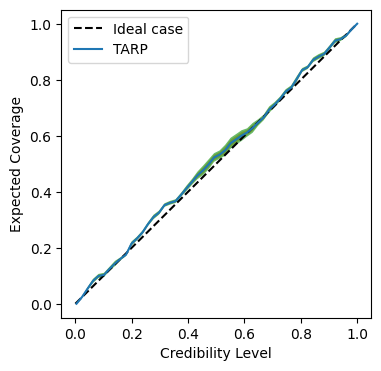

In [76]:
k_sigma = [1, 2, 3]

_, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.plot([0, 1], [0, 1], ls='--', color='k', label="Ideal case")
ax.plot(alpha, ecp_bootstrap.mean(axis=0), label='TARP')
for k in k_sigma:
    ax.fill_between(alpha, 
                    ecp_bootstrap.mean(axis=0) - k * ecp_bootstrap.std(axis=0), 
                    ecp_bootstrap.mean(axis=0) + k * ecp_bootstrap.std(axis=0), 
                    alpha = 0.7)
ax.legend()
ax.set_ylabel("Expected Coverage")
ax.set_xlabel("Credibility Level")
plt.show()

# if curve is below the ideal case, the model is overconfident
# if curve is above the ideal case, the model is conservative (ensembles should be more conservative)

# Test inference on synthetic data for both recruitment scenarios and variants

In [ ]:
n_samples = 100

test_scenarios_posterior_samples = {}
for test_scenario in valid_data_dict.keys():
    print(f"Testing scenario {test_scenario}")
    test_sims = trainer.configurator(valid_data_dict[test_scenario])
    posterior_samples = trainer.amortizer.sample(test_sims, n_samples=n_samples)
    posterior_samples = renormalize_params(posterior_samples, keep_log_transform=True)
    test_scenarios_posterior_samples[test_scenario] = posterior_samples
    if isinstance(test_sims, list):  # for ensemble
        prior_draws = renormalize_params(test_sims[0]["parameters"], keep_log_transform=True)
    else:
        prior_draws = renormalize_params(test_sims["parameters"], keep_log_transform=True)
    fig = bf.diagnostics.plot_recovery(posterior_samples, prior_draws,
                                       ylabel=f'Estimated\n{test_scenario}',
                                       param_names=log_param_names)
    fig.savefig(f'{results_folder}/{amortizer_name}_recovery_{test_scenario}.png')
    plt.show()

## Bias Estimation

bias found in simulation study (when using PedCov as selection procedure) with MCMC:
- overestimation of mu_inf_SA, mu_inf_AA (infectiousness of adults)
- underestimation of mu_susc_A (susceptibility of adults)

Here we should not see any bias anymore, since we condition on the recruitment procedure and variant.

### Simulation Study

All parameters are set to 1 besides one parameter. Inference workflow applied on the full model still. Check if for the changing parameter the true parameter is still recovered.

In [ ]:
# generate simulation study or load data
simulation_study_file_name = "sim_study_data_both_variants"
n_sims_per_param = 50

np.random.seed(42)
temp = np.random.uniform(1, 3, (n_sims_per_param // 2, n_params))
prior_draws_sim_study = np.log(np.concatenate((1./temp, temp)))
non_fix_indices_study = np.arange(n_params)
fix_indices_study = np.array([param_names.index('beta'), param_names.index('delta')])
non_fix_indices_study = np.delete(non_fix_indices_study, fix_indices_study)
prior_draws_sim_study[:, fix_indices_study] = np.array([np.log(0.2), 1.3])

    
sim_study_dict = {}
sim_study_bias_dict = {}

for variant, selection in product(['alpha', 'omicron'], ['pedcov', 'random']):
    
    study_file_name_vs = f"{simulation_study_file_name}_{variant}_{selection}"
    if os.path.exists(f'{sim_folder}/{study_file_name_vs}.pickle'):
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'rb') as f:
            sim_study_dict[f'{variant}_{selection}'] = pickle.load(f)
    else:
        print(f"Simulating simulation study for {variant} with {selection}")
        if variant == 'alpha':
            community_infection = 0.002
        else:
            community_infection = 0.02
        
        new_sim_data = {
            'prior_draws': np.zeros((len(non_fix_indices_study), n_sims_per_param, n_params)),  # all parameters are set to log(1)
            'sim_batchable_context': np.array([[selection, community_infection] 
                                               for _ in range(len(non_fix_indices_study))]),
            'sim_non_batchable_context': variant,
            'sim_data': np.empty((len(non_fix_indices_study), n_sims_per_param,
                                  valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[1],
                                  valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[2], 
                              valid_data_dict[f'{variant}_{selection}']['sim_data'].shape[3])),
        }
        for i, index_i in enumerate(non_fix_indices_study):
            # set all except the i-th parameter to log(1)
            new_sim_data['prior_draws'][i, :, index_i] = prior_draws_sim_study.copy()[:, index_i]
            new_sim_data['prior_draws'][i, :, fix_indices_study] = prior_draws_sim_study.copy()[:, fix_indices_study].T  # fix params
            new_sim_data['sim_data'][i] = np.array([
            simulator(log_params=params,
                      batchable_context=new_sim_data['sim_batchable_context'][i],
                      non_batchable_context=variant)
            for params in new_sim_data['prior_draws'][i]
            ])

        # save the data
        with open(f'{sim_folder}/{study_file_name_vs}.pickle', 'wb') as f:
            pickle.dump(new_sim_data, f)
        sim_study_dict[f'{variant}_{selection}'] = new_sim_data

In [ ]:
# perform inference on simulation study
results_sim_study = {} 
n_samples_study = 10  # increase for more accurate results, e.g. 1000 samples
keep_log_transform = False

for selection_data, selection_inference in tqdm(product(['pedcov', 'random'], ['pedcov', 'random']), total=4):
    for variant in ['alpha', 'omicron']:
        # estimate median and CI for each parameter
        results_sim_study_vs = {
            'posterior_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'posterior_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
            'relative_bias_median': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'relative_bias_CI': np.ones((len(non_fix_indices_study), 6, n_sims_per_param)) * np.nan,
            'overall_median_error': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan,
            'n_infected_rel': np.ones((len(non_fix_indices_study), n_sims_per_param)) * np.nan
        }
        for i, index_i in enumerate(non_fix_indices_study):
            test = sim_study_dict[f'{variant}_{selection_inference}']['sim_batchable_context'][i]
            # get data for this parameter
            sim_study_i = {
                'sim_data': sim_study_dict[f'{variant}_{selection_data}']['sim_data'][i],
                'prior_draws': sim_study_dict[f'{variant}_{selection_data}']['prior_draws'][i],
                # on purpose a different selection procedure than the data was generated with
                'sim_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_batchable_context'][i],
                'sim_non_batchable_context': sim_study_dict[f'{variant}_{selection_inference}']['sim_non_batchable_context']
            }
            simulation_study_data_conf = trainer.configurator(sim_study_i)
            # get posterior samples
            posterior_samples_sim_study = (
                trainer.amortizer.sample(simulation_study_data_conf, n_samples=n_samples_study)
            )
            posterior_samples_sim_study = renormalize_params(posterior_samples_sim_study, 
                                                             keep_log_transform=keep_log_transform)
            if isinstance(simulation_study_data_conf, list):  # for ensemble
                prior_draws_study = renormalize_params(simulation_study_data_conf[0]['parameters'], 
                                                       keep_log_transform=keep_log_transform)
            else:
                prior_draws_study = renormalize_params(simulation_study_data_conf['parameters'], 
                                                       keep_log_transform=keep_log_transform)
    
            # get median and CI for each parameter of posterior samples
            # we only care about the changing parameter, the others are set to 1
            results_sim_study_vs['posterior_median'][i] = np.median(posterior_samples_sim_study[:, :, index_i], axis=1)
            results_sim_study_vs['posterior_CI'][i] = np.quantile(posterior_samples_sim_study[:, :, index_i],
                                                                    [0.005, 0.025, 0.1,
                                                                     0.995, 0.975, 0.9],
                                                                    axis=1)
             # get median and CI for each parameter of relative bias (estimate - true) / true
            relative_bias = (posterior_samples_sim_study[:, :, index_i] - prior_draws_study[:, index_i][:, np.newaxis]) / prior_draws_study[:, index_i][:, np.newaxis]
            results_sim_study_vs['relative_bias_median'][i] = np.median(relative_bias, axis=1)
            results_sim_study_vs['relative_bias_CI'][i] = np.quantile(relative_bias,
                                                                        [0.005, 0.025, 0.1,
                                                                         0.995, 0.975, 0.9],
                                                                        axis=1)
            # get overall median error
            results_sim_study_vs['overall_median_error'][i] = np.sum(
                (np.median(posterior_samples_sim_study, axis=1) - prior_draws_study)**2, axis=1
            )
            
            # get number of infected people in that dataset
            results_sim_study_vs['n_infected_rel'][i] = percentage_infection_age(sim_study_i['sim_data'],
                                                                                 param_names[index_i])

        results_sim_study[f'{selection_data}_{selection_inference}_{variant}'] = results_sim_study_vs

In [ ]:
# plot the results
prior_transformed = renormalize_params(prior_draws_sim_study, keep_log_transform=keep_log_transform)

for selection_data, selection_inference in product(['pedcov', 'random'], ['pedcov', 'random']):
    fig, ax = plt.subplots(2, len(non_fix_indices_study), sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
    space = 1. / n_sims_per_param
    ci_level = 0.95
    ci_interval = {0.99: [0, 3], 0.95: [1, 4], 0.8: [2, 5]}[0.95]
    colors = ['#1f78b4', '#b2df8a']
    
    for i, index_i in enumerate(non_fix_indices_study):
        relative_alpha = results_sim_study[f'{selection_data}_{selection_inference}_alpha']['relative_bias_median'][i]
        relative_omicron = results_sim_study[f'{selection_data}_{selection_inference}_omicron']['relative_bias_median'][i]
        
        # compute the error of the CI
        alpha_err = np.abs(results_sim_study[f'{selection_data}_{selection_inference}_alpha']['relative_bias_CI'][i][ci_interval] - 
                           results_sim_study[f'{selection_data}_{selection_inference}_alpha']['relative_bias_median'][i])
        omicron_err = np.abs(results_sim_study[f'{selection_data}_{selection_inference}_omicron']['relative_bias_CI'][i][ci_interval] - 
                             results_sim_study[f'{selection_data}_{selection_inference}_omicron']['relative_bias_median'][i])

        
        plot_alpha = np.ones(prior_transformed[:, index_i].shape[0], dtype=bool)
        plot_omicron = np.ones(prior_transformed[:, index_i].shape[0], dtype=bool)
        n_infected_rel_a = results_sim_study[f'{selection_data}_{selection_inference}_alpha']['n_infected_rel'][i].copy()
        n_infected_rel_o = results_sim_study[f'{selection_data}_{selection_inference}_omicron']['n_infected_rel'][i].copy()
        #plot_alpha = n_infected_rel_a > np.median(n_infected_rel_a)
        #plot_omicron = n_infected_rel_o > np.median(n_infected_rel_o)
        #plot_alpha =  prior_transformed[:, index_i] > 0.5
        for j in range(relative_alpha.shape[0]):
            handle_alpha = ax[0, i].errorbar(prior_transformed[:, index_i][j],
                                             relative_alpha[j],
                                             yerr=alpha_err[:, j][:, np.newaxis],
                                             fmt='o', color=colors[0], alpha=1 if plot_alpha[j] else 0.1, 
                                             label='Alpha')
            handle_omicron = ax[1, i].errorbar(prior_transformed[:, index_i][j],
                                               relative_omicron[j],
                                               yerr=omicron_err[:, j][:, np.newaxis],
                                               fmt='o', color=colors[1], alpha=1 if plot_omicron[j] else 0.1,
                                               label='Omicron')

        handle_alpha_mean = ax[0, i].errorbar(1.5,
                                              np.median(relative_alpha[plot_alpha]),
                                              yerr=np.std(relative_alpha[plot_alpha]),
                                              color='black', marker='x', label=r'Median bias ($\pm$ std)', zorder=4)

        handle_omicron_mean = ax[1, i].errorbar(1.5,
                                                np.median(relative_omicron[plot_omicron]),
                                                yerr=np.std(relative_omicron[plot_omicron]),
                                                color='black', marker='x', label=r'Median bias ($\pm$ std)', zorder=4)

        ax[0, i].axhline(0, color='black', ls='--', zorder=3)
        ax[1, i].axhline(0, color='black', ls='--', zorder=3)
        
        ax[1, i].set_xlabel(param_names[index_i])
        ax[1, i].set_xlim(-0.5, 3.5)
        ax[1, i].set_xticks(np.arange(4))
        ax[0, 0].set_ylim(-1.5, 8)
    ax[0, 0].set_ylabel(f'Relative Bias\n(Median, {round(ci_level*100)}% CI)')
    ax[1, 0].set_ylabel(f'Relative Bias\n(Median, {round(ci_level*100)}% CI)')
    ax[0, n_params//2-1].set_title(f'Simulation Study - Data: {selection_data}, Inference: {selection_inference}')  
    fig.legend(handles=[handle_alpha, handle_omicron, handle_alpha_mean],
                loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
    fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_'
                f'{selection_data}_vs_inference_{selection_inference}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# plot bias in both scenarios
fig, ax = plt.subplots(2, len(non_fix_indices_study), sharex=True, sharey=True, figsize=(10, 6), tight_layout=True)
colors = ['#d95f02', '#7570b3']

for j, (selection_data, selection_inference) in enumerate(product(['pedcov', 'random'], ['pedcov', 'random'])):
    if selection_data != selection_inference:
        # using the wrong condition can be used as sanity check
        continue
    for i, index_i in enumerate(non_fix_indices_study):
        # plot a line around 0
        ax[0, i].axhline(0, color='black', ls='--', zorder=3)
        ax[1, i].axhline(0, color='black', ls='--', zorder=3)

        relative_alpha = results_sim_study[f'{selection_data}_{selection_inference}_alpha']['relative_bias_median'][i]
        relative_omicron = results_sim_study[f'{selection_data}_{selection_inference}_omicron']['relative_bias_median'][i]

        # Define the error as [lower_error, upper_error]
        lower_quantile, upper_quantile = np.quantile(relative_alpha, [0.025, 0.975])
        yerr_alpha = np.array([[np.median(relative_alpha) - lower_quantile],
                               [upper_quantile - np.median(relative_alpha)]])
        lower_quantile, upper_quantile = np.quantile(relative_omicron, [0.025, 0.975])
        yerr_omicron = np.array([[np.median(relative_omicron) - lower_quantile],
                                 [upper_quantile - np.median(relative_omicron)]])


        handle_alpha_mean = ax[0, i].errorbar(
            j,
            np.median(relative_alpha),
            yerr=yerr_alpha,
            color=colors[j // 2], marker='x', label=r'Median Bias', zorder=4
        )
        handle_omicron_mean = ax[1, i].errorbar(
            j,
            np.median(relative_omicron),
            yerr=yerr_omicron,
            color=colors[j // 2], marker='x', label=r'Median Bias', zorder=4
        )
        ax[0, i].set_title(param_names[index_i])
        #ax[1, i].set_xlim(-0.5, 3.5)
        ax[1, i].set_xlim(-1.5, 4.5)
        ax[1, i].set_ylim(-1, 4)
        #ax[1, i].set_xticks([0, 1, 2, 3], labels=['PedCov', 'Random', 'PedCov', 'Random'], rotation=60)
        ax[1, i].set_xticks([0, 3], labels=['PedCov', 'Random'], rotation=60)
        ax[0, 0].set_ylabel('Median Relative Bias \n Alpha')
        ax[1, 0].set_ylabel('Median Relative Bias \n Omicron')
        
color_patch = [Patch(color=colors[i], label=f'Data generated with {["PedCov", "Random"][i]}') for i in range(2)]
leg = fig.legend(handles=color_patch, bbox_to_anchor=(0.5, -0.05), loc='lower center', ncol=2)
fig.savefig(f'{results_folder}/{amortizer_name}_sim_study_data_bias.png', bbox_inches='tight')
plt.show()

# Apply inference on real data

In [ ]:
# specify the data path
data_path_alpha = 'Simulator/pedcovid_data_structure_alpha.txt'  # todo: exchange with real data of alpha
data_path_omicron = 'Simulator/pedcovid_data_structure_omicron.txt'  # todo: exchange with real data of omicron
os.makedirs(results_folder+'/real data', exist_ok=True)

community_infection = {  # must be one of the predefined values, otherwise networks are unreliable
    'alpha': 0.002,
    'omicron': 0.02
}

In [ ]:
# load the data
dfs = {
    'alpha': pd.read_csv(data_path_alpha, delimiter=' ', index_col=0),
    'omicron': pd.read_csv(data_path_omicron, delimiter=' ', index_col=0)
}
prior_samples = renormalize_params(prior(1000))

real_data = {
    'alpha': None,
    'omicron': None
}

# prepare the data for neural networks
for variant in ['alpha', 'omicron']:
    household_data = normalize_household_data(dfs[variant], minimal_length=9)[np.newaxis]
    real_data[variant] = {
        'sim_data': household_data,
        'sim_non_batchable_context': variant,
        'sim_batchable_context': ['pedcov', community_infection[variant]]
    }
    real_data[variant].update({'configured_data': trainer.configurator(real_data[variant])})

In [ ]:
# get posterior samples
for variant in ['alpha', 'omicron']:
    posterior_samples_real = (
        trainer.amortizer.sample(real_data[variant]['configured_data'], n_samples=prior_samples.shape[0])
    )    
    real_data[variant]['posterior_samples'] = renormalize_params(posterior_samples_real)
    
    # save to csv
    pd.DataFrame(real_data[variant]['posterior_samples'], columns=param_names).to_csv(
        f'{results_folder}/real data/posterior_samples_{variant}.csv'
    )
    
    # compute MAP
    #posterior_samples_prop = (
    #    trainer.amortizer.log_posterior(real_data[variant]['configured_data'])
    #)
    #real_data[variant]['MAP'] = renormalize_params(posterior_samples_real[np.argmax(posterior_samples_prop)][np.newaxis], #keep_log_transform=True)[0]

In [ ]:
# plot posterior samples vs prior
for variant in ['alpha', 'omicron']:
    print(f"Variant: {variant}")
    fig = bf.diagnostics.plot_posterior_2d(
        posterior_draws=real_data[variant]['posterior_samples'],
        prior_draws=prior_samples,
        param_names=param_names,
        label_fontsize=22,
        legend_fontsize=24
    )
    ax = fig.get_axes()
    for i, a in enumerate(ax):
        # plot only on the diagonal
        if i == i // len(param_names) * (len(param_names)+1):
            a.axvline(1, color='b')
    plt.savefig(f'{results_folder}/real data/posterior_{variant}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# plot credible intervals for each parameter and each variant
for variant in ['alpha', 'omicron']:
    ax = sampling_parameter_cis(real_data[variant]['posterior_samples'], alpha=[99, 95, 80],
                                param_names=param_names, title=f"Real Data Posterior CIs - {variant}")
    # add vertical line at 1 for the mu parameters
    ax.vlines(1, ymin=1.75, ymax=8.25, color='grey', linestyle='--')
    plt.savefig(f'{results_folder}/real data/CIs_{variant}.png', bbox_inches='tight')
    plt.show()

In [ ]:
# plot credible intervals for each parameter and both variants
param_samples_both_list = []
param_names_list_both = []
for p_i in range(n_params):
    param_samples_both_list.append(real_data['alpha']['posterior_samples'][:, p_i])
    param_samples_both_list.append(real_data['omicron']['posterior_samples'][:, p_i])
    
    param_names_list_both.append('alpha ' + param_names[p_i])
    param_names_list_both.append('omicron ' + param_names[p_i])
    
# Sort param names based on the part after the first underscore
sorted_indices = [param_names_list_both.index(variant) for variant in sorted(param_names_list_both, key=lambda x: x.split(' ', 1)[1])]
    
ax = sampling_parameter_cis(np.array(param_samples_both_list).T[:, sorted_indices], alpha=[99, 95, 80],
                       param_names=np.array(param_names_list_both)[sorted_indices], title=f"Real Data Posterior CIs")
# add vertical line at 1 for the mu parameters
ax.vlines(1, ymin=3.75, ymax=17.25, color='grey', linestyle='--')
plt.savefig(f'{results_folder}/real data/CIs_both.png', bbox_inches='tight')
plt.show()

In [ ]:
# compute statistics for real data and the simulation study
# compute number of infected individuals based on age, household size
from helper_functions import get_household_statistic
from plotting_functions import plot_household_statistic

real_data_stats = {
    'alpha': None,
    'omicron': None
}

sim_data_stats = {
    'alpha': None,
    'omicron': None
}
status_names = ['not_infected', 'infected_symptomatic', 'infected_asymptomatic']
colors_age = {
    '<6 years': '#b2df8a',
    '6-11 years': '#d95f02',
    '>11 years': '#1f78b4'
}
colors_status = {
    'infected_symptomatic': '#1f78b4',
    'infected_asymptomatic': '#b2df8a'
}

for variant in ['alpha', 'omicron']:
    # original_pedcov is pedcov selection, but tries to get unique households (so exactly the same as real data)
    sim_data_median = simulator(
        log_params=np.median(real_data['alpha']['posterior_samples'], axis=0),
        batchable_context=['pedcov', community_infection[variant]],
        non_batchable_context=variant
    )
        
    real_data_stats[variant] = get_household_statistic(real_data[variant]['sim_data'][0])
    sim_data_stats[variant] = get_household_statistic(sim_data_median)
    sim_data_stats[variant].update({'sim_data_median': sim_data_median})

In [ ]:
# plot the statistics
plot_household_statistic(real_data_stats, sim_data_stats, results_folder)  